In [8]:
import numpy as np
import arcpy
import os
import pickle
import pandas as pd
from arcgis.features.feature import arcpy
import random
from arcpy.sa import *
from osgeo import gdal
#import geopandas as gpd
#from pysal.model.spvcm.verify import weights

In [2]:
arcpy.env.overwriteOutput = True
# Set the workspace (geodatabase) for ArcPy operations
arcpy.env.workspace =  r"D:\itay\ABM\Prj_25.gdb" #change to relevant
# Read shapefile containing geographic boundaries
#gdf = gpd.read_file(r"C:\Users\Owner\Documents\Itay\thesis\HN_ext.shp")

# Extract the coordinates from the geometry to define the study area bounds
coords = [139558.1607, 478519.3236, 209577.0318, 557944.894200001]
#for geometry in gdf.geometry:
#    x, y = geometry.exterior.coords.xy
#    coords.extend([min(x), min(y), max(x), max(y)])

# Create the Extent object that defines the geographic boundaries for analysis
extent = arcpy.Extent(*coords)
print(extent)
# Set the extent as the current environment extent
arcpy.env.extent = extent

# Define paths to various input datasets used in the model
param0=r"D:\itay\ABM\Prj_25.gdb\Jaxa_israel_Clip"

139558.1607 478519.3236 209577.0318 557944.894200001 NaN NaN NaN NaN


In [3]:
# Determine cell size for the simulation
# Original cell size
ras = arcpy.sa.Raster(param0)
orig_cell_size = ras.meanCellWidth  # Assuming square cells, else also check meanCellHeight
print(f"Original cell size: {orig_cell_size} m")

# New cell size (larger for simulation efficiency)
new_cell_size = 250

# Calculate scale factor for resampling
scale_factor = new_cell_size / orig_cell_size

# Original dimensions of the raster
orig_cols = ras.width
orig_rows = ras.height
print(f"Original dimensions: {orig_rows} rows, {orig_cols} columns")

# Calculate new dimensions after resampling
new_cols = math.ceil(orig_cols / scale_factor)
new_rows = math.ceil(orig_rows / scale_factor)

print(f"New dimensions: {new_rows} rows, {new_cols} columns")

Original cell size: 12.5 m
Original dimensions: 6355 rows, 5602 columns
New dimensions: 318 rows, 281 columns


In [11]:
param0=r"D:\itay\ABM\Prj_25.gdb\Jaxa_israel_Clip"
param1=r"D:\itay\ABM\Prj_25.gdb\slope"
param2= 500
param3 = r"D:\itay\ABM\Prj_25.gdb\rain_mean"
param4 = r"D:\itay\ABM\Prj_25.gdb\Veg_values"
param5 = r"D:\itay\ABM\Prj_25.gdb\p_water"
param6 = r"D:\itay\ABM\Prj_25.gdb\aspect"
param7 = r"D:\itay\ABM\Prj_25.gdb\kadesh_barnea"
param8 = r"D:\itay\ABM\Prj_25.gdb\agri_soils"
param9=r"D:\itay\ABM\Prj_25.gdb\cisterns"
#constant_raster = arcpy.sa.CreateConstantRaster(0, cell_size=100)
#output_raster_path = r"D:\itay\ABM\Prj_25.gdb\blank_YEAR"
#constant_raster.save(output_raster_path)
param10=r"D:\itay\ABM\Prj_25.gdb\blank_YEAR" #replace to relevant
param11 = r"D:\itay\ABM\Prj_25.gdb\Veg_values"
param12 = r"D:\itay\ABM\Prj_25.gdb\Flow_Direct"
param13 = r"D:\itay\ABM\Prj_25.gdb\Watershed_un_p"
param14 = r"D:\itay\ABM\Prj_25.gdb\Watersh_Agri_soil"
param15=r"E:\AA\GIS data\PythonProject\rasters\cost_dist\cost_surface_hours_per_meter.tif"
itm_spatial_reference = arcpy.SpatialReference(2039)
arcpy.env.outputCoordinateSystem = itm_spatial_reference
base_directory = r"D:\itay\ABM\years.gdb"
base_dir = r"D:\itay\ABM\years.gdb"
dump_directory = r"D:\itay\ABM\Prj_25.gdb"
##take care
rain_data=pd.read_csv(r"D:\itay\Model_2024\all_by_S.csv", encoding='Windows-1255')
rp=r"D:\itay\ABM\Prj_25.gdb\rain_points_2023"

In [31]:
# Pre-calculate data outside the loop (run once)
years_columns = rain_data.columns[rain_data.columns.str.match('\d{4}$')]
stations_count_per_year = rain_data[years_columns].count()
years_with_20_stations = stations_count_per_year[stations_count_per_year >= 20].index.tolist()

# Pre-load static raster
param11_raster = arcpy.Raster(param11) / 12.3287 * 10

# Optimized function
def yearly_suitability(param0, param3, param9, param8, param4, param12, param13, param14, param15, param11_raster, years_with_20_stations, i):
    # Set extent once
    des = arcpy.Describe(param3)
    extent1 = des.extent
    arcpy.env.extent = arcpy.Extent(extent1.XMin, extent1.YMin, extent1.XMax, extent1.YMax)

    # Select random year
    selected_year = random.choice(years_with_20_stations)

    # IDW interpolation
    output_raster = os.path.join(base_directory, 'Y{}_rain_map'.format(i))
    y_r = arcpy.sa.Idw(rp, selected_year, 100)
    y_r.save(output_raster)

    # Rain fuzzy membership - combine calculations
    Yrain_FuzzyAlgorithm = FuzzyLinear(0, 100)
    YrainFuzzyMember_calc = FuzzyMembership(y_r, Yrain_FuzzyAlgorithm) * 10
    YrainFuzzyMember_calc.save(os.path.join(base_directory, 'Y{}_rain_fit'.format(i)))

    # Agricultural basins
    y_r_resampled = arcpy.management.Resample(y_r, os.path.join(arcpy.env.scratchGDB, 'y_r_resampled_{}'.format(i)), "10")

    # Calculate statistics
    yiag_zonal_mean = arcpy.sa.ZonalStatistics(param14, "VALUE", y_r_resampled, "MEAN")
    yiag_zonal_p25 = arcpy.sa.ZonalStatistics(param14, "VALUE", y_r_resampled, "PERCENTILE", percentile_value=25)

    # Combine thresholds into source raster
    source_raster = arcpy.sa.Con(
        (yiag_zonal_mean >= 75) & (yiag_zonal_p25 >= 60),
        1
    )

    # Check if any zones passed the threshold
    try:
        source_max = arcpy.management.GetRasterProperties(source_raster, "MAXIMUM").getOutput(0)
        zones_passed = source_max is not None and float(source_max) > 0
    except:
        zones_passed = False

    if zones_passed:
        # Normal processing: calculate distance accumulation
        DistAc_tempag_Yi = arcpy.sa.DistanceAccumulation(
            in_source_data=source_raster,
            in_cost_raster=param15
        )

        # Save temporarily to calculate statistics
        temp_dist_path = os.path.join(arcpy.env.scratchGDB, 'temp_dist_{}'.format(i))
        DistAc_tempag_Yi.save(temp_dist_path)

        # Get mean value from saved raster
        ag_mean_value = arcpy.management.GetRasterProperties(temp_dist_path, "MEAN")

        # Fuzzy membership for agriculture
        ag_FuzzyAlgorithm = FuzzySmall(ag_mean_value, 1)
        agr_raster = FuzzyMembership(temp_dist_path, ag_FuzzyAlgorithm) * 10
        agr_raster.save(os.path.join(base_directory, 'Y{}fit_Dist_tempag'.format(i)))

        # Clean up temp distance raster
        arcpy.management.Delete(temp_dist_path)
    else:
        # No zones passed: create constant 0 raster
        print(f"  No zones passed threshold in iteration {i} - creating 0 raster")
        agr_raster = arcpy.sa.CreateConstantRaster(0, "FLOAT", y_r.meanCellWidth, y_r.extent)
        agr_raster.save(os.path.join(base_directory, 'Y{}fit_Dist_tempag'.format(i)))

    # Pastoral potential - use pre-calculated raster
    calc_pastoral_Yi = param11_raster * (YrainFuzzyMember_calc / 10)
    calc_pastoral_Yi.save(os.path.join(base_directory, 'Y{}_past_fit'.format(i)))

    # Clean up temporary data
    arcpy.management.Delete(y_r_resampled)

    return [calc_pastoral_Yi, agr_raster, YrainFuzzyMember_calc]

# Run the loop for 75 iterations
y_outputs = []
for i in range(44,75):  # 0 to 74
    print(f"Processing iteration {i}/75...")
    output = yearly_suitability(
        param0, param3, param9, param8, param4, param12, param13,
        param14, param15, param11_raster, years_with_20_stations, i
    )
    y_outputs.append(output)

print("All 75 iterations complete!")

Processing iteration 44/75...
Processing iteration 45/75...
Processing iteration 46/75...
Processing iteration 47/75...
Processing iteration 48/75...
Processing iteration 49/75...
Processing iteration 50/75...
Processing iteration 51/75...
Processing iteration 52/75...
Processing iteration 53/75...
Processing iteration 54/75...
Processing iteration 55/75...
Processing iteration 56/75...
Processing iteration 57/75...
  No zones passed threshold in iteration 57 - creating 0 raster
Processing iteration 58/75...
Processing iteration 59/75...
  No zones passed threshold in iteration 59 - creating 0 raster
Processing iteration 60/75...
Processing iteration 61/75...
Processing iteration 62/75...
Processing iteration 63/75...
Processing iteration 64/75...
Processing iteration 65/75...
Processing iteration 66/75...
Processing iteration 67/75...
Processing iteration 68/75...
Processing iteration 69/75...
Processing iteration 70/75...
Processing iteration 71/75...
Processing iteration 72/75...
Pr

In [33]:
y_outputs_path=[]
for i in range(75):
    year_i=[]
    year_i.append(os.path.join(base_directory, 'Y{}_rain_fit'.format(i)))
    year_i.append(os.path.join(base_directory, 'Y{}fit_Dist_tempag'.format(i)))
    year_i.append(os.path.join(base_directory, 'Y{}_past_fit'.format(i)))
    y_outputs_path.append(year_i)



In [ ]:
y_outputs = []

# Run the function x times
x=75
for i in range(x):
    # Call the function and append the output to the list
    output = yearly_suitability(param0, param3, param9, param8, param4, param12, param13, param14,param15, i)
    print(i)
    y_outputs.append(output)

In [ ]:
# Load previously saved outputs from a pickle file
y1_outputs = None
file_path = r"C:\Users\Owner\Documents\Itay\y_outputs.pkl"
with open(file_path, 'rb') as f:
    y1_outputs = pickle.load(f)

y1_outputs

In [34]:

def rasterlist_to_life(rasterlist):
    """
    Converts a list of raster file paths into actual ArcPy Raster objects.

    Parameters:
    - rasterlist: A nested list of raster file paths

    Returns:
    - ys_output: A nested list of ArcPy Raster objects
    """
    ys_output = []
    for i in range(len(rasterlist)):
        l = []
        for j in range(len(rasterlist[i])):
            raster_path = rasterlist[i][j]
            l.append(arcpy.Raster(raster_path))
        ys_output.append(l)
    return ys_output

# Convert the list of raster paths to actual Raster objects
y_output = rasterlist_to_life(y_outputs_path)

In [37]:
pext = arcpy.sa.Raster(param0)
lowerLeft = arcpy.Point(pext.extent.XMin, pext.extent.YMin)
print(lowerLeft)

139554.92519999 478515.532299997 NaN NaN


In [38]:
numpy_list=[]
for i in range(len(y_output)):
    l=[]
    for j in range(len(y_output[i])):
        raster_path = y_output[i][j]
        raster_cell_size = raster_path.meanCellWidth
        l.append(arcpy.RasterToNumPyArray(raster_path, lowerLeft,ncols=raster_path.width,nrows=raster_path.height))
    numpy_list.append(l)

In [61]:
y_output[0][1].meanCellWidth

12.5

In [57]:
numpy_list[0][1].shape

(6360, 5600)

In [ ]:
pext = arcpy.sa.Raster(param0)
lowerLeft = arcpy.Point(pext.extent.XMin, pext.extent.YMin)
raster_path = y_output[3][-1]
Raster = arcpy.Raster(raster_path)
raster_cell_size = raster_path.meanCellWidth
nump = arcpy.RasterToNumPyArray(
    raster_path,
    lowerLeft,
    ncols=int(Raster.width ),
    nrows=int(Raster.height )
)


In [ ]:
import matplotlib.pyplot as plt

plt.imshow(place_raster, cmap='viridis')
plt.colorbar(label="Raster Values")
plt.title("Raster Data Plot")
plt.xlabel("X Coordinates")
plt.ylabel("Y Coordinates")
plt.show()

In [67]:
from scipy.ndimage import zoom
# Now resample all arrays to the target cell size
resampled_list = []
cell_sizes=[100,12.5,100]
target_cell_size=250
for i in range(len(numpy_list)):
    resampled_sublist = []

    for j in range(len(numpy_list[i])):
        # Get current array and cell size
        array = numpy_list[i][j]
        raster_path = y_output[i][j]
        raster_cell_size = raster_path.meanCellWidth
        current_cell_size = raster_cell_size

        # Calculate scaling factor
        # When resampling to larger cell size (e.g., from 12.5 to 250),
        # we need a scale factor < 1 to reduce array dimensions
        scale_factor = current_cell_size / target_cell_size

        # Skip resampling if already at target cell size
        if abs(scale_factor - 1.0) < 0.001:
            resampled_sublist.append(array)
            continue

        # Apply resampling
        # order=1 for bilinear interpolation, order=0 for nearest neighbor
        resampled_array = zoom(array, scale_factor, order=1, prefilter=True)

        resampled_sublist.append(resampled_array)

    resampled_list.append(resampled_sublist)

In [68]:
resampled_list[15][1].shape

(318, 280)

In [69]:
expected=(318, 280)
for i in range(len(resampled_list)):
    for j in range(len(resampled_list[i])):
        if resampled_list[i][j].shape[0] != expected[0] or resampled_list[i][j].shape[1] != expected[1]:
            print(resampled_list[i][j].shape, i, j)

In [71]:
import h5py
# Define the directory path
output_dir = r"/"

# Create the filename with path
output_file = os.path.join(output_dir, "yearly_data_10_25.h5")

with h5py.File(output_file, 'w') as f:
    # Create a group to store metadata if needed
    metadata = f.create_group('metadata')
    metadata.attrs['num_groups'] = len(resampled_list)
    metadata.attrs['arrays_per_group'] = len(resampled_list[0])
    metadata.attrs['array_shape'] = resampled_list[0][0].shape

    # Store each array with compression
    for i in range(len(resampled_list)):
        group = f.create_group(f'group_{i}')
        for j in range(len(resampled_list[i])):
            group.create_dataset(
                f'array_{j}',
                data=resampled_list[i][j],
                compression='gzip',
                compression_opts=4
            )

print(f"Saved {len(resampled_list)} groups with {len(resampled_list[0])} arrays each to {output_dir}")


Saved 75 groups with 3 arrays each to D:\itay\ABM


In [ ]:
loaded_list = []
with h5py.File(output_file, 'r') as f:
    # Get number of groups from metadata
    num_groups = f['metadata'].attrs['num_groups']

    # Load each group
    for i in range(num_groups):
        group_arrays = []
        group = f[f'group_{i}']

        # Get arrays in this group
        num_arrays = len(group.keys())

        for j in range(num_arrays):
            # Load array
            array = np.array(group[f'array_{j}'])
            group_arrays.append(array)

        loaded_list.append(group_arrays)

# permanent

In [ ]:
DistAc_perwat=arcpy.sa.Raster(r'D:\itay\ABM\Prj_25.gdb\Distanc_p_wa1')
arcpy.CalculateStatistics_management(DistAc_perwat)

pw_raster_obj = arcpy.Raster(DistAc_perwat)
pw_mean_value = arcpy.management.GetRasterProperties(pw_raster_obj, "MEAN")
# Create the FuzzySmall algorithm object
pw_midpoint = pw_mean_value
pw_spread = 1
pw_FuzzyAlgorithm = arcpy.sa.FuzzySmall(pw_midpoint, pw_spread)
# Execute FuzzyMembership
pwFuzzyMember = arcpy.sa.FuzzyMembership(DistAc_perwat, pw_FuzzyAlgorithm)
pwFuzzyMember_calc = (pwFuzzyMember * 10)
# Save the output

In [ ]:
fuzzDistAc_perwat_path =os.path.join(r'D:\itay\ABM\Prj_25.gdb','fit_dist_perwater1')
pwFuzzyMember_calc.save(fuzzDistAc_perwat_path)

In [ ]:
pwFuzzyMember_calc

In [139]:
#Import Permanent rasters
l=[r'D:\itay\ABM\Prj_25.gdb\fit_Dist_ags',             # Agricultural soil distance
r'D:\itay\ABM\Prj_25.gdb\fit_Dist_kadeshb',           # Distance to Kadesh Barnea
r'D:\itay\ABM\Prj_25.gdb\fit_dist_perwater',          # Distance to permanent water sources
r"D:\itay\ABM\Prj_25.gdb\veg_fit",                    # Vegetation suitability
r'D:\itay\ABM\Prj_25.gdb\annual_rain_fit',            # Mean Annual rainfall suitability
r'D:\itay\ABM\Prj_25.gdb\slope_suitability']          # Slope suitability for occupation

# Function to convert a list of raster paths to actual raster objects
def rasterlist_to_life1(rasterlist):
   """Load a list of raster paths into ArcPy raster objects"""
   output=[]
   for i in range(len(rasterlist)):
       raster_path = rasterlist[i]
       output.append(arcpy.Raster(raster_path))

   return output

# Load all permanent factors as raster objects
permanent_results=rasterlist_to_life1(l)

# Unpack the rasters into named variables for easier reference
agri_raster, kb_suitability_raster,  pw_suitability_raster, veg_fit, rain_suitability_raster,  slp_suitability_raster = permanent_results

In [140]:
pext = arcpy.sa.Raster(param0)
lowerLeft = arcpy.Point(pext.extent.XMin, pext.extent.YMin)
numpy_per_list=[]
for i in range(len(permanent_results)):
    raster_path = permanent_results[i]
    raster_cell_size = raster_path.meanCellWidth
    arr=arcpy.RasterToNumPyArray(raster_path, lowerLeft,ncols=raster_path.width,nrows=raster_path.height, nodata_to_value=0)
    numpy_per_list.append(arr)

In [141]:
from scipy.ndimage import zoom
resampled_per_list = []
cell_sizes=[item.meanCellWidth for item in permanent_results]
target_cell_size=250
for i in range(len(numpy_per_list)):
    # Get current array and cell size
    array = numpy_per_list[i]
    current_cell_size = cell_sizes[i]

    # Calculate scaling factor
    # When resampling to larger cell size (e.g., from 12.5 to 250),
    # we need a scale factor < 1 to reduce array dimensions
    scale_factor = current_cell_size / target_cell_size

    # Skip resampling if already at target cell size
    if abs(scale_factor - 1.0) < 0.001:
        resampled_per_list.append(array)
        continue

    # Apply resampling
    # order=1 for bilinear interpolation, order=0 for nearest neighbor
    resampled_array = zoom(array, scale_factor, order=1, prefilter=True)

    resampled_per_list.append(resampled_array)



In [142]:
expected=(318, 280)
for i in range(len(resampled_per_list)):
    for j in range(len(resampled_per_list[i])):
        if resampled_per_list[i].shape[0] != expected[0] or resampled_per_list[i].shape[1] != expected[1]:
            print(resampled_per_list[i].shape, i)

In [143]:
import h5py
# Define the directory path
output_dir = r"/"

# Create the filename with path
output_file = os.path.join(output_dir, "per_data_10_25.h5")

with h5py.File(output_file, 'w') as f:
    # Create a group to store metadata if needed
    metadata = f.create_group('metadata')
    metadata.attrs['num_groups'] = 1
    metadata.attrs['arrays_per_group'] = len(resampled_per_list)
    metadata.attrs['array_shape'] = resampled_per_list[0].shape
    group = f.create_group(f'group_{1}')
    # Store each array with compression
    for i in range(len(resampled_per_list)):
            group.create_dataset(
                f'array_{i}',
                data=resampled_per_list[i],
                compression='gzip',
                compression_opts=4
            )

print(f"Saved {1} groups with {len(resampled_per_list)} arrays each to {output_file}")


Saved 1 groups with 6 arrays each to D:\itay\ABM\per_data_10_25.h5


In [80]:
place_ras = arcpy.sa.Raster(r'D:\itay\ABM\Prj_25.gdb\placement_extent_Raster')
place_raster = arcpy.RasterToNumPyArray(place_ras, lower_left_corner=lowerLeft,
                                        ncols=280, nrows=new_rows, nodata_to_value=0)


In [81]:
ext_ras=arcpy.sa.Raster(r'D:\itay\ABM\Prj_25.gdb\HN_Ext_ras')
ext_raster = arcpy.RasterToNumPyArray(ext_ras, lower_left_corner=lowerLeft,ncols=280, nrows=new_rows, nodata_to_value=0)
output_file = os.path.join(output_dir, "ext_raster.npy")
np.save(output_file, ext_raster)
print(f"Place raster saved to {output_file}")

Place raster saved to D:\itay\ABM\ext_raster.npy


In [82]:
output_file = os.path.join(output_dir, "place_raster.npy")
np.save(output_file, place_raster)
print(f"Place raster saved to {output_file}")

Place raster saved to D:\itay\ABM\place_raster.npy


In [145]:
# Open the HDF5 file in read mode
permanent_results=[]
file_path = r"../Data/per_data_10_25.h5"  #list of numpy arrays [distance from loess, distance from
with h5py.File(file_path, 'r') as f:
    # Access metadata
    metadata = f['metadata']
    num_groups = metadata.attrs['num_groups']
    arrays_per_group = metadata.attrs['arrays_per_group']
    array_shape = metadata.attrs['array_shape']

    # Load the arrays from the groups

    for i in range(num_groups):
        group = f[f'group_{i+1}']
        group_arrays = [np.array(group[f'array_{j}']) for j in range(arrays_per_group)]
        permanent_results=group_arrays

In [146]:
permanent_results[1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

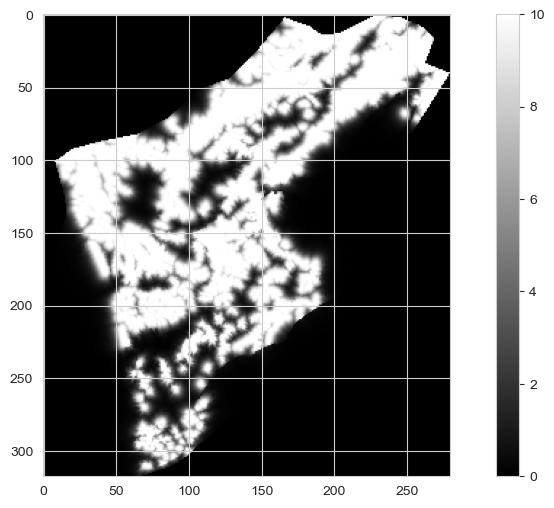

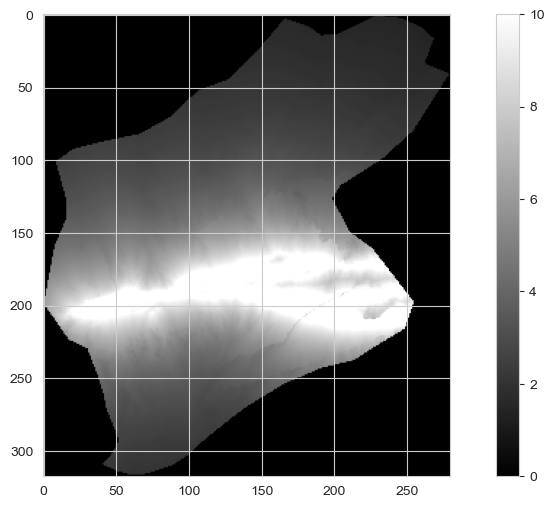

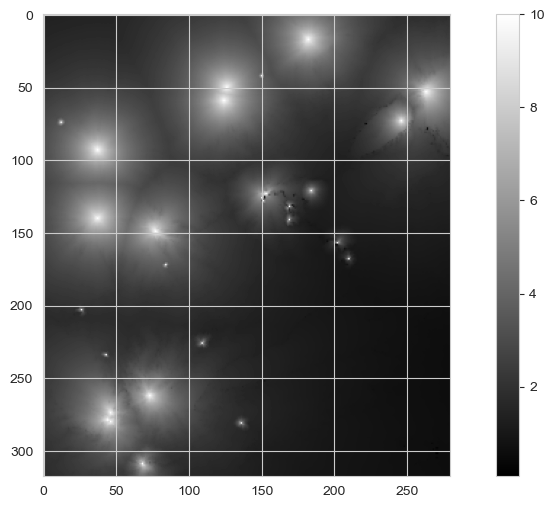

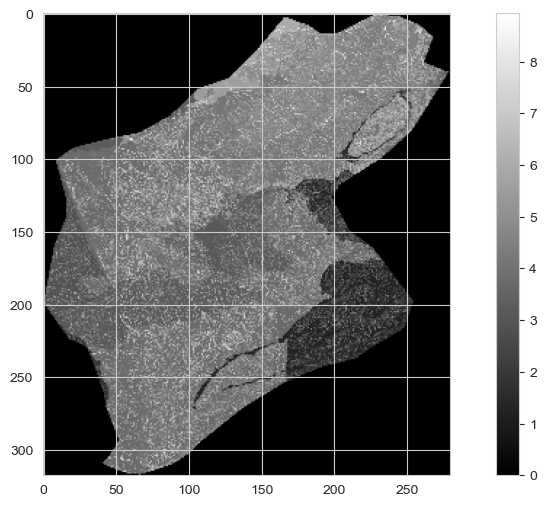

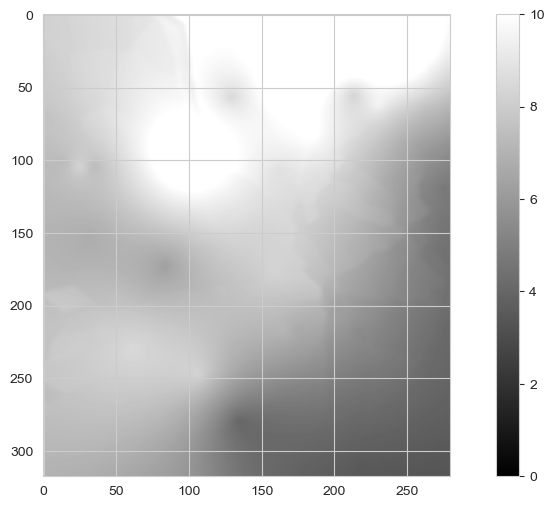

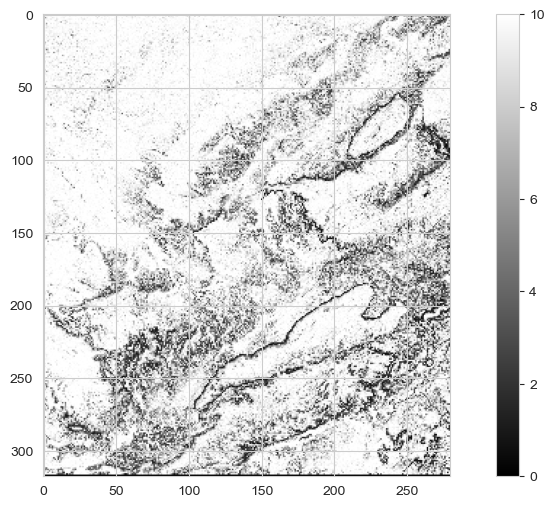

In [147]:
import matplotlib.pyplot as plt
for i in range(len(permanent_results)):
    plt.figure(figsize=(12, 6))
    plt.imshow(permanent_results[i], cmap="gray")
    plt.colorbar()

    plt.show()